In [1]:
import subprocess, io
import pandas as pd
import matplotlib.pyplot as plt

SCRIPT = "borough_complaints.py"
DATA = "data/311_only_2024.csv"

def run_cli(start, end):
    out = subprocess.run(
        ["python", SCRIPT, "-i", DATA, "-s", start, "-e", end],
        capture_output=True, text=True, check=True
    ).stdout
    return pd.read_csv(io.StringIO(out))

In [2]:
full = run_cli("2024-01-01", "2024-12-31")
totals = full.groupby("complaint type")["count"].sum().sort_values(ascending=False)
top_type = totals.index[0]
print(totals.head(10))
print("Top complaint type:", top_type)

complaint type
Illegal Parking            505733
Noise - Residential        379297
HEAT/HOT WATER             264746
Blocked Driveway           170192
Noise - Street/Sidewalk    163002
UNSANITARY CONDITION       120903
Street Condition            72485
Abandoned Vehicle           70326
Noise - Commercial          68347
PLUMBING                    65933
Name: count, dtype: int64
Top complaint type: Illegal Parking


borough
BROOKLYN         31702
QUEENS           23255
BRONX            11836
MANHATTAN        10872
STATEN ISLAND     2245
Unspecified          6
Name: count, dtype: int64 
Total: 79916


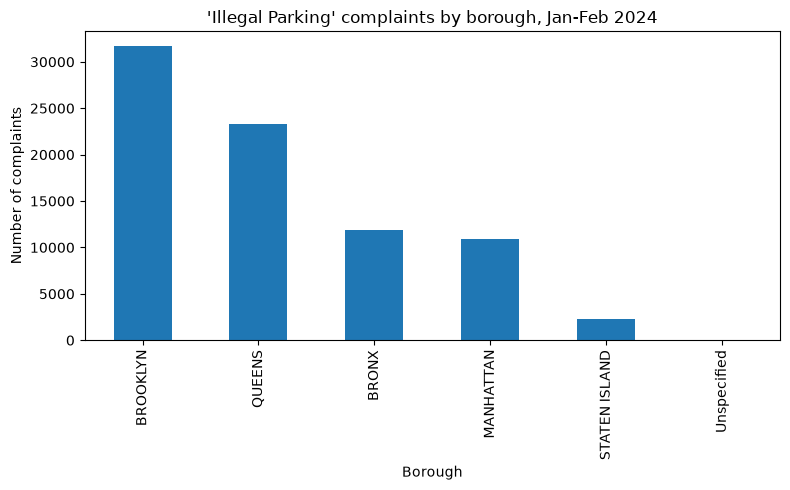

In [3]:
early = run_cli("2024-01-01", "2024-02-29")   # 2024 is a leap year
early_top = early[early["complaint type"] == top_type].set_index("borough")["count"]
print(early_top, "\nTotal:", early_top.sum())

early_top.plot(kind="bar", figsize=(8, 5))
plt.title(f"'{top_type}' complaints by borough, Jan-Feb 2024")
plt.xlabel("Borough")
plt.ylabel("Number of complaints")
plt.tight_layout()
plt.show()

               Jan-Feb  Jun-Jul
borough                        
BROOKLYN         31702    32078
QUEENS           23255    25863
BRONX            11836    13189
MANHATTAN        10872    12366
STATEN ISLAND     2245     2734
Unspecified          6       10 
Totals:
 Jan-Feb    79916
Jun-Jul    86240
dtype: int64


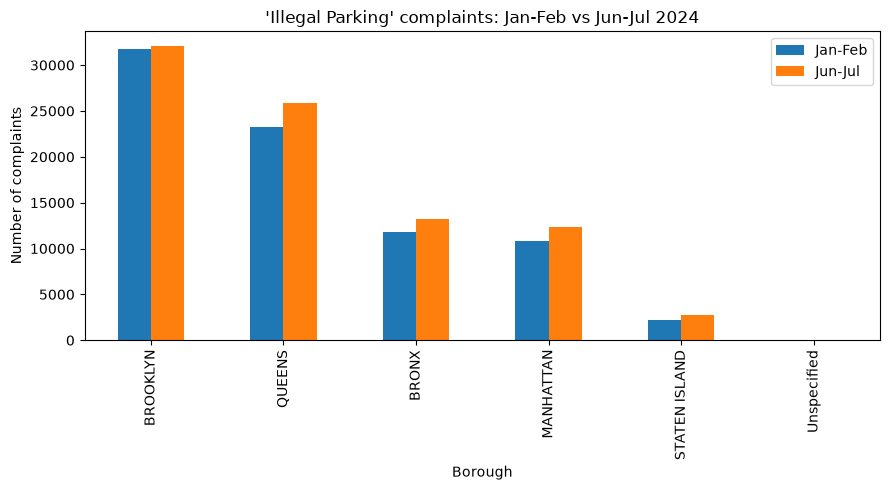

In [4]:
summer = run_cli("2024-06-01", "2024-07-31")
summer_top = summer[summer["complaint type"] == top_type].set_index("borough")["count"]

compare = pd.DataFrame({"Jan-Feb": early_top, "Jun-Jul": summer_top}).fillna(0)
print(compare, "\nTotals:\n", compare.sum())

compare.plot(kind="bar", figsize=(9, 5))
plt.title(f"'{top_type}' complaints: Jan-Feb vs Jun-Jul 2024")
plt.xlabel("Borough")
plt.ylabel("Number of complaints")
plt.tight_layout()
plt.show()

In [5]:
import csv, collections

counts = collections.Counter()
with open("data/311_only_2024.csv", newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        d = row["Created Date"]
        counts[d[6:10] + "-" + d[:2]] += 1

for k in sorted(counts):
    print(k, counts[k])

2024-01 287200
2024-02 240454
2024-03 266700
2024-04 267608
2024-05 284102
2024-06 306407
2024-07 299269
2024-08 285183
2024-09 306973
2024-10 306860
2024-11 293560
2024-12 314004
